# Logistic Regression Scorecard

## I. Import Data and Set Up Environment

In [1]:
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

# Pipeline paths
BASE_DIR = os.getcwd()
PKL_INPUT_DIR = os.path.join(BASE_DIR, 'dataset', 'processed', 'assessment')
PKL_OUT_DIR = os.path.join(BASE_DIR, 'dataset', 'processed', '03')
os.makedirs(PKL_OUT_DIR, exist_ok=True)

# Load feature-engineered data from 01_Data_Preparation_and_EDA.ipynb
application_train = joblib.load(os.path.join(PKL_INPUT_DIR, 'application_train_fe.pkl'))
application_test = joblib.load(os.path.join(PKL_INPUT_DIR, 'application_test_fe.pkl'))
final_feature_cols = joblib.load(os.path.join(PKL_INPUT_DIR, 'final_feature_cols.pkl'))

# Verify load results
print('Data loading complete:')
print(f'  Input directory                  : {PKL_INPUT_DIR}')
print(f'  Notebook 02 output directory      : {PKL_OUT_DIR}')
print(f'  application_train shape : {application_train.shape}')
print(f'  application_test  shape : {application_test.shape}')
print(f'  Number of features                : {len(final_feature_cols)}')
print(f'\nTARGET distribution:')
print(application_train['TARGET'].value_counts())
print(f'Default rate:{application_train["TARGET"].mean():.4%}')


Data loading complete:
  Input directory                  : /Users/fanhongquan/Desktop/project 1 assignment 2/dataset/processed/assessment
  Notebook 02 output directory      : /Users/fanhongquan/Desktop/project 1 assignment 2/dataset/processed/03
  application_train shape : (307511, 532)
  application_test  shape : (48744, 531)
  Number of features                : 530

TARGET distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64
Default rate:8.0729%


In [2]:
# Check missing values
# ── Missing values in the training set ────────────────────────────────────────────────────
train_miss = application_train[final_feature_cols].isnull().sum()
train_miss_rate = train_miss / len(application_train) * 100

# ── Missing values in the test set ────────────────────────────────────────────────────
test_feature_cols = [c for c in final_feature_cols if c in application_test.columns]
test_miss = application_test[test_feature_cols].isnull().sum()
test_miss_rate = test_miss / len(application_test) * 100

# ── Summary statistics ──────────────────────────────────────────────────────────
n_train_miss_cols = (train_miss > 0).sum()
n_test_miss_cols  = (test_miss  > 0).sum()

print('=' * 55)
print('[Missing Value Check Summary]')
print(f'  Training set: {len(final_feature_cols)} features in total; features with missing values: {n_train_miss_cols}')
print(f'  Test set: {len(test_feature_cols)} features in total; features with missing values: {n_test_miss_cols}')
print('=' * 55)

# ── Display the top 20 training-set missing-value rates ───────────────────────────────────────────
miss_df = pd.DataFrame({
    'train_missing_count': train_miss,
    'train_missing_rate%': train_miss_rate.round(2),
    'test_missing_count':  test_miss.reindex(train_miss.index).fillna(0).astype(int),
    'test_missing_rate%':  test_miss_rate.reindex(train_miss.index).fillna(0).round(2),
})
miss_df = miss_df[miss_df['train_missing_count'] > 0].sort_values('train_missing_rate%', ascending=False)

print(f'\nFeatures with missing values (sorted by training-set missing rate in descending order; {len(miss_df)} total):')
print(miss_df.to_string())

[Missing Value Check Summary]
  Training set: 530 features in total; features with missing values: 0
  Test set: 530 features in total; features with missing values: 0

Features with missing values (sorted by training-set missing rate in descending order; 0 total):
Empty DataFrame
Columns: [train_missing_count, train_missing_rate%, test_missing_count, test_missing_rate%]
Index: []


In [3]:
# Missing-value imputation
# ── Fill missing values in all feature columns of the training and test sets with -1 ────────────────────────
application_train[final_feature_cols] = application_train[final_feature_cols].fillna(-1)

test_feature_cols = [c for c in final_feature_cols if c in application_test.columns]
application_test[test_feature_cols] = application_test[test_feature_cols].fillna(-1)

# ── Check again after imputation to confirm that no missing values remain ───────────────────────────────────
train_miss_after = application_train[final_feature_cols].isnull().sum().sum()
test_miss_after  = application_test[test_feature_cols].isnull().sum().sum()

print('[Missing-value imputation complete (fill value = -1)]')
print(f'  Training set — total remaining missing values: {train_miss_after}  {"✓ clean" if train_miss_after == 0 else "✗ missing values remain!"}')
print(f'  Test set — total remaining missing values: {test_miss_after}   {"✓ clean" if test_miss_after  == 0 else "✗ missing values remain!"}')

[Missing-value imputation complete (fill value = -1)]
  Training set — total remaining missing values:0  ✓ clean
  Test set — total remaining missing values:0   ✓ clean


## II. Pre-modeling Encoding

### 2.1 Label Encoding

In [4]:
from sklearn.preprocessing import LabelEncoder

# ── Copy the data to avoid modifying the original data ────────────────────────────────────────
app_train_le = application_train.copy()
app_test_le  = application_test.copy()

# ── Inspect the current object-type columns ────────────────────────────────────────────
obj_cols = app_train_le.select_dtypes(include='object').columns.tolist()
print(f'Number of object-type columns: {len(obj_cols)}')
for col in obj_cols:
    print(f'  {col:<45} nunique={app_train_le[col].nunique()}  '
          f'missing={app_train_le[col].isna().sum()}')

object type columns:16
  NAME_CONTRACT_TYPE                            nunique=2  missing=0
  CODE_GENDER                                   nunique=3  missing=0
  FLAG_OWN_CAR                                  nunique=2  missing=0
  FLAG_OWN_REALTY                               nunique=2  missing=0
  NAME_TYPE_SUITE                               nunique=8  missing=0
  NAME_INCOME_TYPE                              nunique=8  missing=0
  NAME_EDUCATION_TYPE                           nunique=5  missing=0
  NAME_FAMILY_STATUS                            nunique=6  missing=0
  NAME_HOUSING_TYPE                             nunique=6  missing=0
  OCCUPATION_TYPE                               nunique=19  missing=0
  WEEKDAY_APPR_PROCESS_START                    nunique=7  missing=0
  ORGANIZATION_TYPE                             nunique=58  missing=0
  FONDKAPREMONT_MODE                            nunique=5  missing=0
  HOUSETYPE_MODE                                nunique=4  missing=0
  WALLSMA

In [5]:
# ── Apply label encoding consistently to all object-type columns ────────────────────────────
# Note: strings are not allowed before WOE encoding, and each feature must retain a single-column structure (no one-hot encoding)
# Fit the same le object on the training and test sets to ensure consistent mappings

le = LabelEncoder()
le_cols = []

for col in obj_cols:
    # Combine all categories from the training and test sets so that le has seen every category
    all_vals = pd.concat([
        app_train_le[col].astype(str),
        app_test_le[col].astype(str)
    ], ignore_index=True)
    le.fit(all_vals)
    app_train_le[col] = le.transform(app_train_le[col].astype(str))
    app_test_le[col]  = le.transform(app_test_le[col].astype(str))
    le_cols.append(col)

print(f'Label encoding complete; {len(le_cols)} columns processed:')
for col in le_cols:
    print(f'  {col}')

print(f'\nEncoded app_train_le shape: {app_train_le.shape}')
print(f'Encoded app_test_le  shape: {app_test_le.shape}')
print(f'Number of remaining object-type columns: {len(app_train_le.select_dtypes(include="object").columns)}')

Label encoding complete; 16 columns processed:
  NAME_CONTRACT_TYPE
  CODE_GENDER
  FLAG_OWN_CAR
  FLAG_OWN_REALTY
  NAME_TYPE_SUITE
  NAME_INCOME_TYPE
  NAME_EDUCATION_TYPE
  NAME_FAMILY_STATUS
  NAME_HOUSING_TYPE
  OCCUPATION_TYPE
  WEEKDAY_APPR_PROCESS_START
  ORGANIZATION_TYPE
  FONDKAPREMONT_MODE
  HOUSETYPE_MODE
  WALLSMATERIAL_MODE
  EMERGENCYSTATE_MODE

Encoded app_train_le shape: (307511, 532)
Encoded app_test_le  shape: (48744, 531)
Number of remaining object-type columns: 0


### 2.2 Chi-square Binning

In [6]:
!pip install optbinning


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [7]:
from optbinning import OptimalBinning
import pickle

# ── Chi-square binning (using optbinning instead of toad.transform.Combiner)───────────
# Note: fit only on the training set to prevent data leakage
# min_bin_size=0.05 corresponds to toad's min_samples=0.05

feature_cols = [c for c in app_train_le.columns
                if c not in ['SK_ID_CURR', 'TARGET']]
y_train = app_train_le['TARGET'].values

binners = {}  # Store the binner for each feature for subsequent transformation and scorecard mapping

for col in feature_cols:
    ob = OptimalBinning(
        name=col,
        dtype='numerical',
        solver='cp',
        min_bin_size=0.05
    )
    ob.fit(app_train_le[col].values, y_train)
    binners[col] = ob

print(f'Chi-square binning complete; number of features processed: {len(binners)}')

# ── Export binning split points and inspect the first five examples ──────────────────────────────────────
print('\nExample split points for the first five features:')
for i, (col, ob) in enumerate(binners.items()):
    splits = ob.splits
    print(f'  {col:<45} bins={len(splits)+1}  split points={splits}')
    if i >= 4:
        break

(CVXPY) May 12 02:47:39 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) May 12 02:47:39 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


Chi-square binning complete; number of features processed: 530

Example split points for the first five features:
  NAME_CONTRACT_TYPE                            bins=2  split points=[0.5]
  CODE_GENDER                                   bins=2  split points=[1.5]
  FLAG_OWN_CAR                                  bins=2  split points=[0.5]
  FLAG_OWN_REALTY                               bins=2  split points=[0.5]
  CNT_CHILDREN                                  bins=2  split points=[0.5]


In [8]:
# ── Apply the binning transformation to the training and test sets ──────────────────────────────────────
def apply_binning(df, binners, feature_cols):
    df_out = df.copy()
    for col in feature_cols:
        if col in binners:
            df_out[col] = binners[col].transform(df[col].values, metric='indices')
    return df_out

app_train_binned = apply_binning(app_train_le, binners, feature_cols)
app_test_binned  = apply_binning(app_test_le,  binners, feature_cols)

print(f'Binned app_train_binned shape: {app_train_binned.shape}')
print(f'Binned app_test_binned  shape: {app_test_binned.shape}')

# ── Validation: inspect the value distribution of a binned column ───────────────────────────────────
sample_col = feature_cols[0]
print(f'\nValue distribution of the binned example column [{sample_col}]:')
print(app_train_binned[sample_col].value_counts().sort_index())

Binned app_train_binned shape: (307511, 532)
Binned app_test_binned  shape: (48744, 531)

Value distribution of the binned example column [NAME_CONTRACT_TYPE]:
NAME_CONTRACT_TYPE
0    278232
1     29279
Name: count, dtype: int64


### 2.3 WOE Encoding

In [9]:
# ── Implement WOE encoding manually ─────────────────────────────────────────────────
# Note:
#   - Fit only on the training set (to calculate the WOE mapping) to prevent data leakage
#   - Transform the test set using the same mapping

def fit_woe(df, feature_cols, target):
    """Calculate the WOE value for each bin of each feature on the training set and return a mapping dictionary"""
    woe_map = {}
    total_bad  = max(df[target].sum(), 1e-6)
    total_good = max((df[target] == 0).sum(), 1e-6)
    for col in feature_cols:
        grouped = df.groupby(col)[target].agg(['sum', 'count'])
        grouped.columns = ['bad', 'total']
        grouped['good']     = grouped['total'] - grouped['bad']
        grouped['bad_pct']  = (grouped['bad']  / total_bad).clip(lower=1e-6)
        grouped['good_pct'] = (grouped['good'] / total_good).clip(lower=1e-6)
        grouped['woe']      = np.log(grouped['good_pct'] / grouped['bad_pct'])
        woe_map[col] = grouped['woe'].to_dict()
    return woe_map

def transform_woe(df, woe_map, feature_cols):
    """Transform the dataset using the WOE mapping"""
    df_out = df.copy()
    for col in feature_cols:
        if col in woe_map:
            df_out[col] = df_out[col].map(woe_map[col])
    return df_out

# ── Feature columns (excluding SK_ID_CURR and TARGET)───────────────────────────────
woe_feature_cols = [c for c in app_train_binned.columns
                    if c not in ['SK_ID_CURR', 'TARGET']]

# ── Fit on the training set ────────────────────────────────────────────────────
woe_map = fit_woe(app_train_binned, woe_feature_cols, 'TARGET')

# ── Transform the training and test sets ────────────────────────────────────────
app_train_woe = transform_woe(app_train_binned, woe_map, woe_feature_cols)
app_test_woe  = transform_woe(
    app_test_binned[app_train_binned.columns.intersection(app_test_binned.columns)],
    woe_map, woe_feature_cols
)

print(f'WOE encoding complete')
print(f'  app_train_woe shape：{app_train_woe.shape}')
print(f'  app_test_woe  shape：{app_test_woe.shape}')

WOE encoding complete
  app_train_woe shape:(307511, 532)
  app_test_woe  shape:(48744, 531)


In [10]:
# ── Validation: inspect the value distribution of a WOE-encoded column ──────────────────────────────
sample_col = woe_feature_cols[0]
print(f'Unique WOE-encoded values for the example column [{sample_col}]:')
print(sorted(app_train_woe[sample_col].unique()))

# ── Check whether any non-numeric columns remain ──────────────────────────────────────────────
remaining_obj = app_train_woe.select_dtypes(include='object').columns.tolist()
remaining_obj = [c for c in remaining_obj if c not in ['SK_ID_CURR']]
print(f'\nRemaining non-numeric columns after encoding (excluding SK_ID_CURR): {remaining_obj}')

# ── Check whether the WOE value range is reasonable (there should be no extreme values)────────────────────────────
woe_cols  = [c for c in app_train_woe.columns if c not in ['SK_ID_CURR', 'TARGET']]
woe_stats = app_train_woe[woe_cols].describe().loc[['min', 'max']]
print(f'\nWOE value range statistics (first five columns shown):')
print(woe_stats.iloc[:, :5])

Unique WOE-encoded values for the example column [NAME_CONTRACT_TYPE]:
[np.float64(-0.036235891261667624), np.float64(0.4155434380703208)]

Remaining non-numeric columns after encoding (excluding SK_ID_CURR): []

WOE value range statistics (first five columns shown):
     NAME_CONTRACT_TYPE  CODE_GENDER  FLAG_OWN_CAR  FLAG_OWN_REALTY  \
min           -0.036236    -0.250931     -0.056242        -0.033490   
max            0.415543     0.154328      0.117353         0.015093   

     CNT_CHILDREN  
min     -0.108657  
max      0.049678  


## III. PSI Stability Testing and Feature Selection

In [11]:
from sklearn.model_selection import train_test_split

train_woe, val_woe = train_test_split(
    app_train_woe,
    test_size=0.2,
    random_state=42,
    stratify=app_train_woe['TARGET']
)

woe_feature_cols = [c for c in app_train_woe.columns
                    if c not in ['SK_ID_CURR', 'TARGET']]

print(f'Training set (train) shape: {train_woe.shape}, default rate: {train_woe["TARGET"].mean():.4%}')
print(f'Validation set (val) shape: {val_woe.shape}, default rate: {val_woe["TARGET"].mean():.4%}')

Training set (train) shape: (246008, 532), default rate: 8.0729%
Validation set (val) shape: (61503, 532), default rate: 8.0728%


In [12]:
# ── Implement PSI calculation manually ─────────────────────────────────────────────────
# PSI interpretation criteria:
#   PSI < 0.1  → the distribution is highly stable and safe to use
#   0.1 ≤ PSI < 0.25 → minor change; monitor it
#   PSI ≥ 0.25 → substantial distribution shift; removal is recommended

def calc_psi_single(expected, actual, bins=10):
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)
    exp_counts = np.histogram(expected, bins=breakpoints)[0]
    act_counts = np.histogram(actual,   bins=breakpoints)[0]
    exp_pct = exp_counts / len(expected)
    act_pct = act_counts / len(actual)
    exp_pct = np.where(exp_pct == 0, 1e-6, exp_pct)
    act_pct = np.where(act_pct == 0, 1e-6, act_pct)
    return np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))

psi_dict = {col: calc_psi_single(train_woe[col].values, val_woe[col].values)
            for col in woe_feature_cols}
psi_series = pd.Series(psi_dict).sort_values()

print(f'PSI calculated for {len(psi_series)} features')
print(f'\nPSI distribution summary:')
print(f'  PSI < 0.1   (highly stable): {(psi_series < 0.1).sum()}')
print(f'  0.1 ≤ PSI < 0.25 (minor change): {((psi_series >= 0.1) & (psi_series < 0.25)).sum()}')
print(f'  PSI ≥ 0.25  (unstable): {(psi_series >= 0.25).sum()}')
print(f'\nTop 10 features by PSI:')
print(psi_series.tail(10))

PSI calculated for 530 features

PSI distribution summary:
  PSI < 0.1   (highly stable): 530
  0.1 ≤ PSI < 0.25 (minor change): 0
  PSI ≥ 0.25  (unstable): 0

Top 10 features by PSI:
client_pos_MONTHS_BALANCE_sum_sum                 0.000236
client_pos_NAME_CONTRACT_STATUS_Active_sum_sum    0.000239
client_pos_MONTHS_BALANCE_sum_min                 0.000260
CNT_FAM_MEMBERS                                   0.000261
previous_DAYS_DECISION_sum                        0.000264
previous_DAYS_LAST_DUE_1ST_VERSION_min            0.000292
client_pos_MONTHS_BALANCE_max_sum                 0.000295
client_inst_DAYS_ENTRY_PAYMENT_sum_sum            0.000305
bureau_CREDIT_ACTIVE_Closed_count                 0.000323
bureau_CREDIT_ACTIVE_Active_count                 0.000338
dtype: float64


In [13]:
# ── Select stable features using the PSI threshold ───────────────────────────────────────────
PSI_THRESHOLD = 0.1

stable_cols = psi_series[psi_series < PSI_THRESHOLD].index.tolist()

keep_cols = ['SK_ID_CURR', 'TARGET'] + stable_cols
train_woe_stable = train_woe[keep_cols]
val_woe_stable   = val_woe[keep_cols]

print(f'PSI threshold: {PSI_THRESHOLD}')
print(f'Number of features before selection: {len(woe_feature_cols)}')
print(f'Number of features after selection: {len(stable_cols)}')
print(f'Number of unstable features removed: {len(woe_feature_cols) - len(stable_cols)}')

PSI threshold: 0.1
Number of features before selection: 530
Number of features after selection: 530
Number of unstable features removed: 0


In [14]:
# ── After PSI filtering, perform another round of feature selection based on IV and correlation ────────────────────

def calc_iv(df, feature, target):
    grouped = df.groupby(feature)[target].agg(['sum', 'count'])
    grouped.columns = ['bad', 'total']
    grouped['good'] = grouped['total'] - grouped['bad']
    total_bad  = max(grouped['bad'].sum(),  1e-6)
    total_good = max(grouped['good'].sum(), 1e-6)
    grouped['bad_pct']  = (grouped['bad']  / total_bad).clip(lower=1e-6)
    grouped['good_pct'] = (grouped['good'] / total_good).clip(lower=1e-6)
    grouped['iv'] = (grouped['good_pct'] - grouped['bad_pct']) * \
                     np.log(grouped['good_pct'] / grouped['bad_pct'])
    return grouped['iv'].sum()

feature_candidates = stable_cols.copy()

# Step 1: Remove features with IV < 0.01
iv_dict    = {col: calc_iv(train_woe_stable, col, 'TARGET') for col in feature_candidates}
iv_series  = pd.Series(iv_dict)
low_iv     = iv_series[iv_series < 0.01].index.tolist()
feature_candidates = [c for c in feature_candidates if c not in low_iv]
print(f'Removed {len(low_iv)} features with IV < 0.01; {len(feature_candidates)} remain')

# Step 2: Remove highly correlated features (Pearson > 0.5), retaining the feature with the higher IV
corr_matrix = train_woe_stable[feature_candidates].corr().abs()
upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr   = []
for col in upper.columns:
    for row in upper.index[upper[col] > 0.5].tolist():
        drop = col if iv_dict.get(col, 0) < iv_dict.get(row, 0) else row
        if drop not in high_corr:
            high_corr.append(drop)
feature_candidates = [c for c in feature_candidates if c not in high_corr]
print(f'Removed {len(high_corr)} highly correlated features (>0.5); {len(feature_candidates)} remain')

final_feature_cols_woe = feature_candidates
train_woe_slct = train_woe_stable[['SK_ID_CURR', 'TARGET'] + final_feature_cols_woe]
val_woe_slct   = val_woe_stable[['SK_ID_CURR', 'TARGET'] + final_feature_cols_woe]

print(f'\nFinal number of retained features: {len(final_feature_cols_woe)}')

Removed 256 features with IV < 0.01; 274 remain
Removed 213 highly correlated features (>0.5); 61 remain

Final number of retained features: 61


## IV. Stepwise Regression

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

def stepwise_selection(X_train, y_train, max_features=20):
    """
    Forward stepwise regression: at each step, add the feature that produces the largest AUC improvement,
    until max_features is reached or no remaining feature can improve the AUC.
    """
    selected = []
    remaining = list(X_train.columns)
    best_auc = 0.0

    print(f'Starting forward stepwise regression; target number of features: {max_features}')
    print('-' * 60)

    while len(selected) < max_features and remaining:
        aucs = {}
        for col in remaining:
            cols = selected + [col]
            lr = LogisticRegression(
                class_weight='balanced', C=0.01,
                solver='saga', max_iter=200,
                random_state=42, n_jobs=-1
            )
            lr.fit(X_train[cols], y_train)
            prob = lr.predict_proba(X_train[cols])[:, 1]
            aucs[col] = roc_auc_score(y_train, prob)

        best_col = max(aucs, key=aucs.get)
        best_auc = aucs[best_col]
        selected.append(best_col)
        remaining.remove(best_col)
        print(f'  Feature {len(selected):>2}: {best_col:<50}  AUC={best_auc:.4f}')

    print('-' * 60)
    print(f'Stepwise regression complete; final number of selected features: {len(selected)}')
    return selected

# ── Prepare the feature matrix ──────────────────────────────────────────────────────
X_step = train_woe_slct[final_feature_cols_woe]
y_step = train_woe_slct['TARGET']

# ── Run stepwise regression (this may take a long time; please wait)─────────────────────────────
selected_features = stepwise_selection(X_step, y_step, max_features=20)

Starting forward stepwise regression; target number of features: 20
------------------------------------------------------------
  Feature 1: EXT_SOURCE_3                                        AUC=0.6580
  Feature 2: EXT_SOURCE_2                                        AUC=0.7108
  Feature 3: EXT_SOURCE_1                                        AUC=0.7227
  Feature 4: PAYMENT_RATE                                        AUC=0.7302
  Feature 5: client_inst_AMT_PAYMENT_min_mean                    AUC=0.7352
  Feature 6: previous_CNT_PAYMENT_max                            AUC=0.7401
  Feature 7: DAYS_EMPLOYED                                       AUC=0.7447
  Feature 8: NAME_CONTRACT_TYPE                                  AUC=0.7474
  Feature 9: client_credit_CNT_DRAWINGS_CURRENT_mean_max         AUC=0.7497
  Feature 10: NAME_EDUCATION_TYPE                                 AUC=0.7517
  Feature 11: client_pos_CNT_INSTALMENT_FUTURE_min_mean           AUC=0.7537
  Feature 12: CODE_GENDER        

Final 20 model features:
   1. EXT_SOURCE_3
   2. EXT_SOURCE_2
   3. EXT_SOURCE_1
   4. PAYMENT_RATE
   5. client_inst_AMT_PAYMENT_min_mean
   6. previous_CNT_PAYMENT_max
   7. DAYS_EMPLOYED
   8. NAME_CONTRACT_TYPE
   9. client_credit_CNT_DRAWINGS_CURRENT_mean_max
  10. NAME_EDUCATION_TYPE
  11. client_pos_CNT_INSTALMENT_FUTURE_min_mean
  12. CODE_GENDER
  13. OWN_CAR_AGE
  14. previous_NAME_CONTRACT_STATUS_Refused_count
  15. previous_AMT_DOWN_PAYMENT_sum
  16. previous_NAME_YIELD_GROUP_low_action_count
  17. client_pos_SK_DPD_DEF_max_mean
  18. DEF_30_CNT_SOCIAL_CIRCLE
  19. previous_DAYS_LAST_DUE_1ST_VERSION_mean
  20. previous_NAME_YIELD_GROUP_high_count


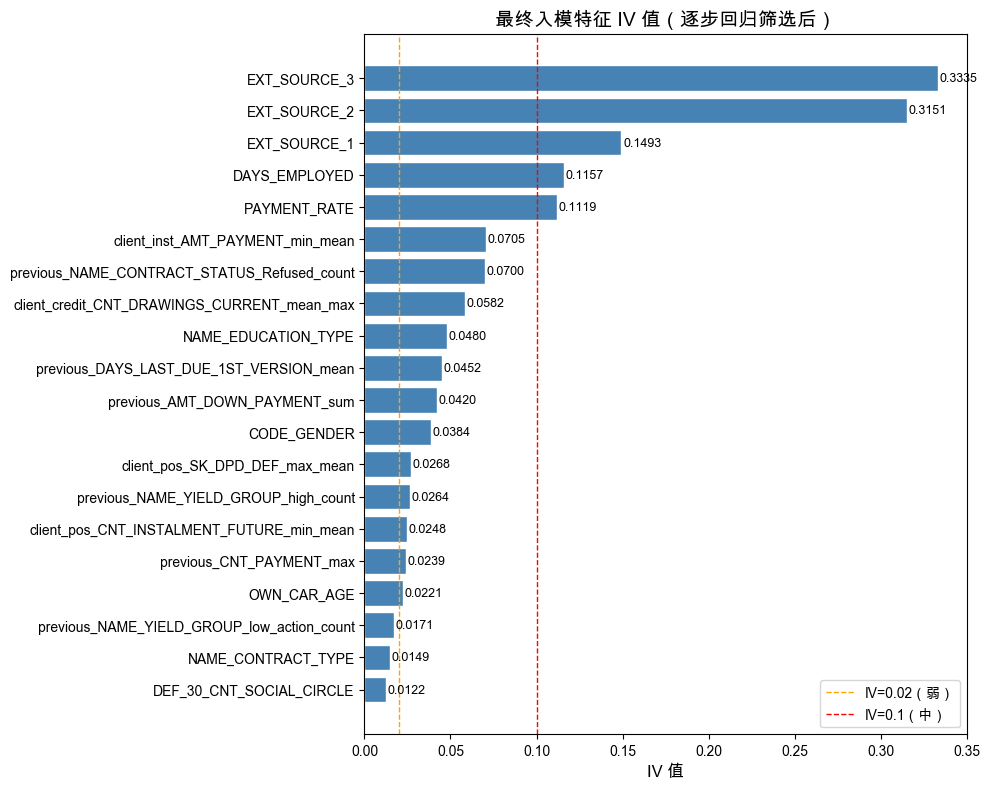

In [16]:
# ── Print the final model features ──────────────────────────────────────────────────
print('Final 20 model features:')
for i, col in enumerate(selected_features, 1):
    print(f'  {i:>2}. {col}')

# ── Calculate the IV value of each feature (for visualization ordering)────────────────────────────
iv_selected = {col: calc_iv(train_woe_slct, col, 'TARGET')
               for col in selected_features}
iv_df = pd.Series(iv_selected).sort_values(ascending=True)

# ── Visualization: horizontal bar chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(len(iv_df)), iv_df.values, color='steelblue', edgecolor='white')

ax.set_yticks(range(len(iv_df)))
ax.set_yticklabels(iv_df.index, fontsize=10)
ax.set_xlabel('IV value', fontsize=12)
ax.set_title('IV Values of Final Model Features (After Stepwise Selection)', fontsize=14)

# Label each bar with its IV value
for i, (bar, val) in enumerate(zip(bars, iv_df.values)):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.axvline(x=0.02, color='orange', linestyle='--', linewidth=1, label='IV=0.02 (weak)')
ax.axvline(x=0.1,  color='red',    linestyle='--', linewidth=1, label='IV=0.1 (medium)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## V. Logistic Regression Modeling and Evaluation

In [17]:
# ── Extract the final model features from the WOE-filtered datasets ──────────────────────────
train_woe_final = train_woe_slct[['SK_ID_CURR', 'TARGET'] + selected_features].copy()
val_woe_final   = val_woe_slct[['SK_ID_CURR', 'TARGET'] + selected_features].copy()

print(f'train_woe_final shape：{train_woe_final.shape}')
print(f'val_woe_final   shape：{val_woe_final.shape}')

train_woe_final shape:(246008, 22)
val_woe_final   shape:(61503, 22)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, classification_report
)

# ── Prepare the feature matrix ──────────────────────────────────────────────────────
X_train = train_woe_final[selected_features]
y_train = train_woe_final['TARGET']
X_val   = val_woe_final[selected_features]
y_val   = val_woe_final['TARGET']

# ── Standardize the data (WOE features already have similar scales, but standardization helps convergence)─────────────────
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

# ── Train the logistic regression model ──────────────────────────────────────────────────────
lr = LogisticRegression(
    class_weight='balanced',
    C=0.01,
    solver='saga',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train_scaled, y_train)
print('Logistic regression training complete.')

# ── 5-fold cross-validation ROC-AUC ───────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr, X_train_scaled, y_train,
                            cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'\n5-fold cross-validation ROC-AUC:')
print(f'  Scores by fold: {[round(s, 4) for s in cv_scores]}')
print(f'  Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'\nBaseline (first notebook): AUC=0.7160, KS=0.3246')

Logistic regression training complete.

5-fold cross-validation ROC-AUC:
  Scores by fold: [np.float64(0.758), np.float64(0.7597), np.float64(0.7662), np.float64(0.765), np.float64(0.7611)]
  Mean: 0.7620 ± 0.0031

Baseline (first notebook): AUC=0.7160, KS=0.3246


Metric                               Training Set             Validation Set
-------------------------------------------------------
ROC-AUC                       0.7623          0.7644
KS                            0.3973          0.4017

Baseline (first notebook): AUC=0.7160, KS=0.3246


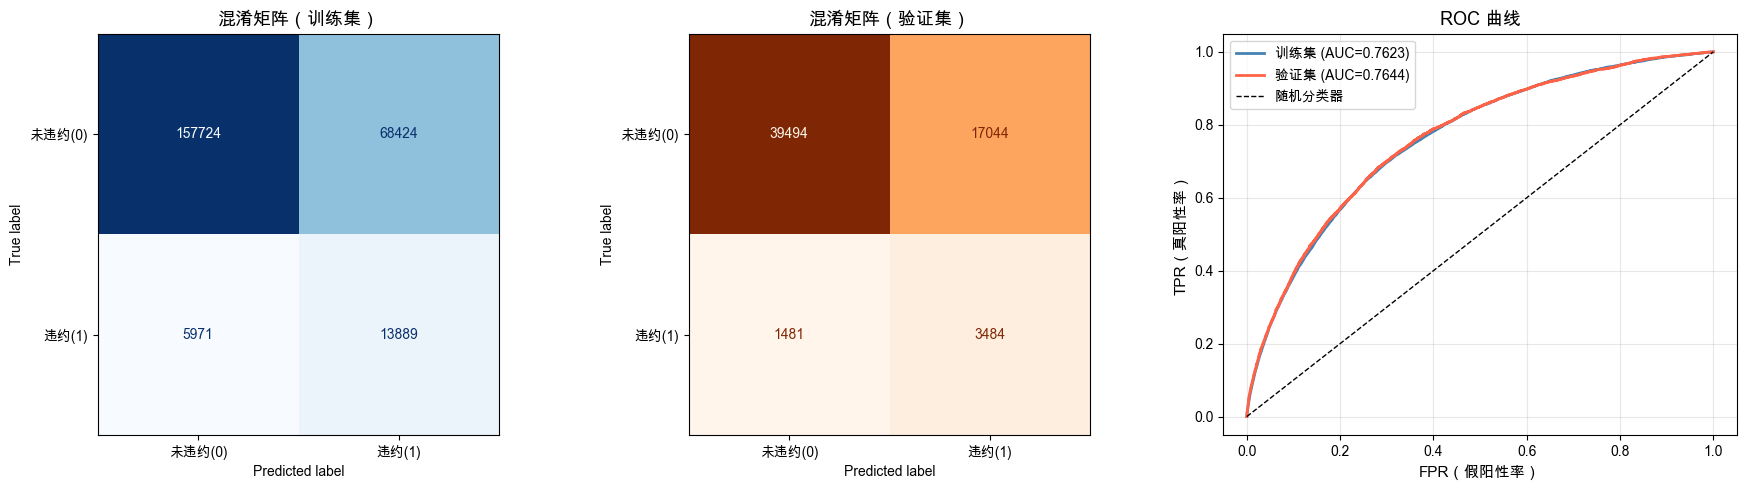

In [19]:
# ── Predict probabilities ──────────────────────────────────────────────────────────
y_train_proba = lr.predict_proba(X_train_scaled)[:, 1]
y_val_proba   = lr.predict_proba(X_val_scaled)[:, 1]
y_train_pred  = lr.predict(X_train_scaled)
y_val_pred    = lr.predict(X_val_scaled)

# ── AUC ───────────────────────────────────────────────────────────────
auc_train = roc_auc_score(y_train, y_train_proba)
auc_val   = roc_auc_score(y_val,   y_val_proba)

# ── KS ────────────────────────────────────────────────────────────────
fpr_tr, tpr_tr, thr_tr = roc_curve(y_train, y_train_proba)
fpr_vl, tpr_vl, thr_vl = roc_curve(y_val,   y_val_proba)
ks_train = (tpr_tr - fpr_tr).max()
ks_val   = (tpr_vl - fpr_vl).max()
ks_thr_train = thr_tr[(tpr_tr - fpr_tr).argmax()]
ks_thr_val   = thr_vl[(tpr_vl - fpr_vl).argmax()]

print('=' * 55)
print(f'{"Metric":<20} {"Training Set":>15} {"Validation Set":>15}')
print('-' * 55)
print(f'{"ROC-AUC":<20} {auc_train:>15.4f} {auc_val:>15.4f}')
print(f'{"KS":<20} {ks_train:>15.4f} {ks_val:>15.4f}')
print('=' * 55)
print(f'\nBaseline (first notebook): AUC=0.7160, KS=0.3246')

# ── Confusion matrices and ROC curve (shown side by side)──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix (Training Set)
cm_tr = confusion_matrix(y_train, y_train_pred)
ConfusionMatrixDisplay(cm_tr, display_labels=['Non-default (0)', 'Default (1)']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Training Set)', fontsize=13)

# Confusion Matrix (Validation Set)
cm_vl = confusion_matrix(y_val, y_val_pred)
ConfusionMatrixDisplay(cm_vl, display_labels=['Non-default (0)', 'Default (1)']).plot(
    ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('Confusion Matrix (Validation Set)', fontsize=13)

# ROC curve (training set vs. validation set)
axes[2].plot(fpr_tr, tpr_tr, color='steelblue', lw=2,
             label=f'Training Set (AUC={auc_train:.4f})')
axes[2].plot(fpr_vl, tpr_vl, color='tomato',    lw=2,
             label=f'Validation Set (AUC={auc_val:.4f})')
axes[2].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
axes[2].set_xlabel('FPR (False Positive Rate)', fontsize=11)
axes[2].set_ylabel('TPR (True Positive Rate)', fontsize=11)
axes[2].set_title('ROC Curve', fontsize=13)
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

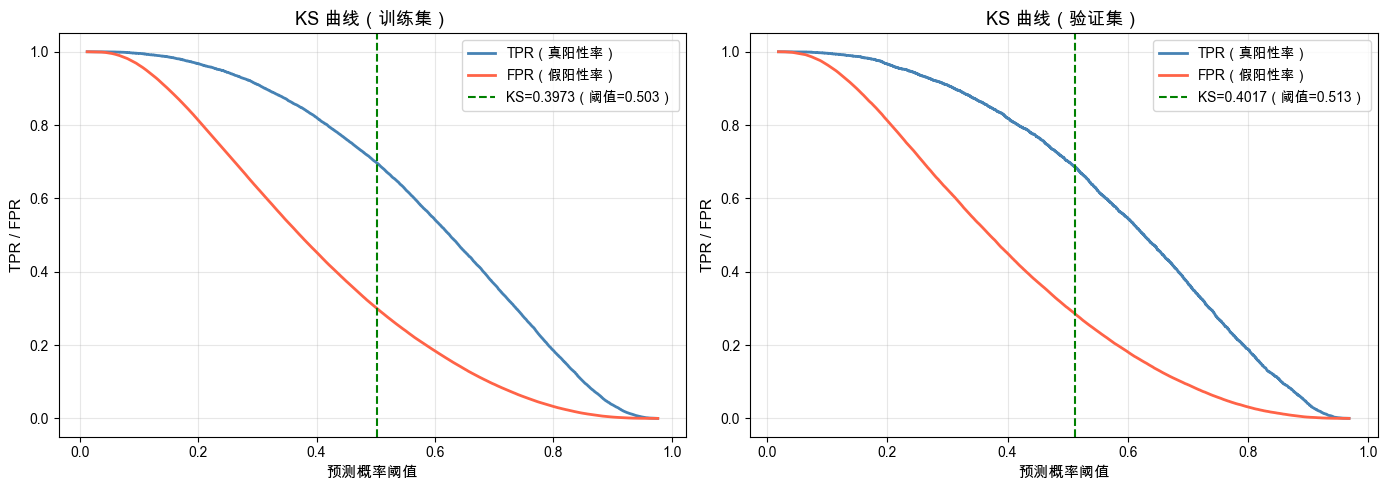


Training Set KS:0.3973 (threshold=0.5026)
Validation Set KS:0.4017 (threshold=0.5128)
Baseline KS (first notebook):0.3246


In [20]:
# ── KS curves (training set vs. validation set)────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, fpr, tpr, thr, ks, ks_thr, title in [
    (axes[0], fpr_tr, tpr_tr, thr_tr, ks_train, ks_thr_train, 'Training Set'),
    (axes[1], fpr_vl, tpr_vl, thr_vl, ks_val,   ks_thr_val,   'Validation Set'),
]:
    ks_vals = tpr - fpr
    thr_plot = thr[:-1] if len(thr) < len(tpr) else thr
    ax.plot(thr_plot, tpr[:len(thr_plot)], color='steelblue', lw=2, label='TPR (True Positive Rate)')
    ax.plot(thr_plot, fpr[:len(thr_plot)], color='tomato',    lw=2, label='FPR (False Positive Rate)')
    ax.axvline(x=ks_thr, color='green', linestyle='--', lw=1.5,
               label=f'KS={ks:.4f} (threshold={ks_thr:.3f})')
    ax.set_xlabel('Predicted Probability Threshold', fontsize=11)
    ax.set_ylabel('TPR / FPR',   fontsize=11)
    ax.set_title(f'KS Curve ({title})', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nTraining-set KS: {ks_train:.4f} (threshold={ks_thr_train:.4f}）')
print(f'Validation-set KS: {ks_val:.4f} (threshold={ks_thr_val:.4f}）')
print(f'Baseline KS (first notebook): 0.3246')

## VI. Logistic Regression Scorecard Mapping

In [21]:
import math

def score_from_proba(p, base_score=600, pdo=50):
    """Calculate the scorecard score from default probability p"""
    # Prevent log errors when p=0 or p=1
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return base_score + pdo * np.log2((1 - p) / p)

# ── Use logistic regression to predict default probability ────────────────────────────────────────────
y_train_proba = lr.predict_proba(X_train)[:, 1]
y_val_proba   = lr.predict_proba(X_val)[:, 1]

# ── Calculate scores ──────────────────────────────────────────────────────────
train_scores = score_from_proba(y_train_proba)
val_scores   = score_from_proba(y_val_proba)

print(f'Training-set score summary:')
print(f'  mean={train_scores.mean():.1f}, standard deviation={train_scores.std():.1f}')
print(f'  minimum={train_scores.min():.1f}, maximum={train_scores.max():.1f}')
print(f'\nValidation-set score summary:')
print(f'  mean={val_scores.mean():.1f}, standard deviation={val_scores.std():.1f}')
print(f'  minimum={val_scores.min():.1f}, maximum={val_scores.max():.1f}')

Training-set score summary:
  mean=642.0, standard deviation=31.4
  minimum=521.8, maximum=740.7

Validation-set score summary:
  mean=642.1, standard deviation=31.3
  minimum=529.1, maximum=737.6


In [22]:
# ── KS binning report (10 equal-frequency bins)────────────────────────────────────────
def ks_bucket_report(scores, y, n_bins=10, title=''):
    df_rep = pd.DataFrame({'score': scores, 'target': y})
    df_rep['bucket'] = pd.qcut(df_rep['score'], q=n_bins, duplicates='drop')
    grouped = df_rep.groupby('bucket', observed=False)['target'].agg(
        总样本='count', 坏样本='sum'
    ).reset_index()
    grouped['好样本']  = grouped['总样本'] - grouped['坏样本']
    grouped['坏样本率'] = (grouped['坏样本'] / grouped['总样本']).round(4)
    total_bad  = grouped['坏样本'].sum()
    total_good = grouped['好样本'].sum()
    grouped['累计坏样本占比'] = (grouped['坏样本'].cumsum() / total_bad).round(4)
    grouped['累计好样本占比'] = (grouped['好样本'].cumsum() / total_good).round(4)
    grouped['KS'] = (grouped['累计坏样本占比'] - grouped['累计好样本占比']).abs().round(4)
    print(f'\n=== {title} KS Binning Report ===')
    print(grouped.to_string(index=False))
    print(f'Maximum KS: {grouped["KS"].max():.4f}')
    return grouped

train_report = ks_bucket_report(train_scores, train_woe_final['TARGET'].values,
                                n_bins=10, title='Training Set')
val_report   = ks_bucket_report(val_scores,   val_woe_final['TARGET'].values,
                                n_bins=10, title='Validation Set')


=== Training Set KS Binning Report ===
                      bucket   Total  Bad   Good   Bad Rate  Cumulative Bad Share  Cumulative Good Share     KS
(521.8140000000001, 600.154] 24601 6382 18219 0.2594   0.3213   0.0806 0.2407
          (600.154, 615.198] 24601 3725 20876 0.1514   0.5089   0.1729 0.3360
          (615.198, 625.869] 24601 2622 21979 0.1066   0.6409   0.2701 0.3708
           (625.869, 634.88] 24600 2034 22566 0.0827   0.7434   0.3698 0.3736
           (634.88, 643.089] 24601 1487 23114 0.0604   0.8182   0.4721 0.3461
            (643.089, 651.3] 24601 1149 23452 0.0467   0.8761   0.5758 0.3003
            (651.3, 659.761] 24600  910 23690 0.0370   0.9219   0.6805 0.2414
          (659.761, 669.293] 24601  701 23900 0.0285   0.9572   0.7862 0.1710
          (669.293, 681.928] 24601  489 24112 0.0199   0.9818   0.8928 0.0890
          (681.928, 740.721] 24601  361 24240 0.0147   1.0000   1.0000 0.0000
Maximum KS: 0.3736

=== Validation Set KS Binning Report ===
       

In [23]:
# ── Generate the customer score master table ──────────────────────────────────────────────────

# Combine the training and validation sets
train_result = train_woe_final[['SK_ID_CURR', 'TARGET']].copy()
train_result['score'] = np.round(train_scores).astype(int)
train_result['数据集'] = '训练集'

val_result = val_woe_final[['SK_ID_CURR', 'TARGET']].copy()
val_result['score'] = np.round(val_scores).astype(int)
val_result['数据集'] = '验证集'

full_result = pd.concat([train_result, val_result], ignore_index=True)

# Convert TARGET to readable labels
full_result['是否违约'] = full_result['TARGET'].map({0: '否', 1: '是'})
full_result = full_result[['SK_ID_CURR', 'score', '是否违约', '数据集']]

# ── Print a preview ──────────────────────────────────────────────────────────
print(f'Customer score master table shape: {full_result.shape}')
print(f'\nPreview of the first 10 rows:')
print(full_result.head(10).to_string(index=False))

print(f'\nScore summary:')
print(f'  All customers: mean={full_result["score"].mean():.1f}，'
      f'minimum={full_result["score"].min()}，maximum={full_result["score"].max()}')
print(f'  Defaulting customers (yes): mean={full_result.loc[full_result["是否违约"]=="是","score"].mean():.1f}')
print(f'  Non-defaulting customers (no): mean={full_result.loc[full_result["是否违约"]=="否","score"].mean():.1f}')

# ── Save the CSV and PKL files required by Notebook 03 ───────────────────────────────────────
os.makedirs(PKL_OUT_DIR, exist_ok=True)
scorecard_path = os.path.join(PKL_OUT_DIR, 'customer_scorecard.csv')
full_result.to_csv(scorecard_path, index=False, encoding='utf-8-sig')

save_dict = {
    'binners.pkl': binners,
    'woe_map.pkl': woe_map,
    'selected_features.pkl': selected_features,
    'scaler.pkl': scaler,
    'lr_model.pkl': lr,
    'train_woe_final.pkl': train_woe_final,
    'val_woe_final.pkl': val_woe_final,
    'customer_scorecard.pkl': full_result,
}

print(f'\nSave Notebook 02 output files to: {PKL_OUT_DIR}')
print('-' * 60)
print(f'  customer_scorecard.csv              ({os.path.getsize(scorecard_path) / 1024 / 1024:.1f} MB)')
for fname, obj in save_dict.items():
    fpath = os.path.join(PKL_OUT_DIR, fname)
    joblib.dump(obj, fpath)
    size_mb = os.path.getsize(fpath) / 1024 / 1024
    print(f'  {fname:<35} ({size_mb:.1f} MB)')
print('-' * 60)
print('Notebook 02 outputs have been saved and can be loaded directly by 03_Prescriptive_Analytics_LP.ipynb.')


Customer score master table shape: (307511, 4)

Preview of the first 10 rows:
 SK_ID_CURR  score Defaulted Dataset
     310536    640    No Training Set
     365516    620    No Training Set
     242055    643    Yes Training Set
     454894    642    Yes Training Set
     448321    600    No Training Set
     333032    672    No Training Set
     200322    630    No Training Set
     360927    641    No Training Set
     149698    625    No Training Set
     378855    628    No Training Set

Score summary:
  All customers: mean=642.0, minimum=522, maximum=741
  Defaulting customers (yes): mean=615.2
  Non-defaulting customers (no): mean=644.3

Save Notebook 02 output files to: /Users/fanhongquan/Desktop/project 1 assignment 2/dataset/processed/03
------------------------------------------------------------
  customer_scorecard.csv              (7.3 MB)
  binners.pkl                         (0.6 MB)
  woe_map.pkl                         (0.0 MB)
  selected_features.pkl               (0